<a href="https://colab.research.google.com/github/iMaIrsdyh/BigData26_B_2411533018_KarimahIrsyadiyah/blob/main/Praktikum3/BD_B_P03_2411533018_KarimahIrsyadiyah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM 3 BIG DATA

**KARIMAH IRSYADIYAH**

**2411533018**

# K. Tutorial Langkah demi Langkah

## **K-1. Menyiapkan Lingkungan dan Memindahkan Perkakas dari Praktikum 1**

Tahap K-1 digunakan untuk menyiapkan lingkungan kerja Google Colab dan fungsi yang akan digunakan selama Praktikum 3.

Beberapa library utama yang digunakan adalah:
- `pandas` dan `numpy` untuk pengolahan data.
- `psutil` untuk mengukur penggunaan memori.
- `requests` untuk mengambil data dari sumber eksternal pada tahap berikutnya.
- `pyarrow` untuk membaca dan menulis file Parquet.
- `sklearn` untuk proses machine learning dan preprocessing.
- `sqlalchemy` untuk mengakses basis data SQLite.

Google Drive dihubungkan agar hasil praktikum dapat disimpan secara permanen. Tiga direktori disiapkan, yaitu:
- `DIR_MENTAH` untuk menyimpan data mentah.
- `DIR_KURASI` untuk menyimpan data yang sudah dikurasi atau dibersihkan.
- `DIR_SIMPAN` untuk menyimpan artefak hasil praktikum.

Fungsi `rss_mb()` digunakan untuk mengetahui penggunaan memori proses dalam satuan MB. Fungsi `ukur()` digunakan untuk mengukur waktu eksekusi dan perubahan penggunaan memori pada suatu proses. Hasil pengukuran disimpan ke dalam list `catatan`.

Praktikum 3 juga memperkenalkan konsep **data lineage**, yaitu pencatatan asal-usul data. Fungsi `catat_sumber()` mencatat nama sumber, asal data, waktu pengambilan, jumlah baris, dan keterangan sumber ke dalam list `lineage`.

Dengan demikian, `catatan` digunakan untuk mencatat biaya komputasi berupa waktu dan memori, sedangkan `lineage` digunakan untuk mencatat asal-usul data. Kedua informasi ini akan digunakan kembali sebagai artefak pada K-10.

In [5]:
import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil

for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"

for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

# --- Dipakai kembali dari Praktikum 1 / K-3 ---
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({
        "langkah": label,
        "detik": round(detik, 2),
        "delta_rss_mb": round(rss_mb() - m0, 1)
    })
    print(f"[{label}] {detik:.2f} s")
    return hasil

# --- Baru di Praktikum 3: catatan asal-usul data (lineage) ---
lineage = []

def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama,
        "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris,
        "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.52
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Pada tahap ini dilakukan pengecekan terhadap library yang dibutuhkan dan penyiapan direktori kerja. Jika library berhasil ditemukan, versinya akan ditampilkan pada output. Google Drive juga akan terhubung ke Google Colab.

Tidak terdapat proses pengolahan dataset pada K-1, sehingga belum ada jumlah baris data yang dianalisis. Fungsi `ukur()` dan `catat_sumber()` juga baru didefinisikan dan belum digunakan untuk mencatat proses pengambilan data.

Hasil penting pada tahap ini adalah lingkungan praktikum berhasil disiapkan dan fungsi pengukuran kinerja serta pencatatan lineage sudah tersedia untuk digunakan pada tahap berikutnya.

**Catatan:** pada modul, `DIR_SIMPAN` diarahkan ke folder `BigData/Praktikum2`, meskipun bagian persiapan Praktikum 3 menyebutkan folder `BigData/Praktikum3`. Kode di atas mengikuti kode K-1 pada modul.

## **K-2. Akuisisi 1 — Unduhan Berkala yang Tahan Gagal**

Pada K-2 dilakukan pengambilan dua sumber data, yaitu data perjalanan taksi Yellow Taxi dari NYC TLC dan data referensi zona taksi. Tahap ini menggunakan mekanisme unduhan yang lebih aman dibandingkan Praktikum 1.

Fungsi `unduh_aman()` digunakan untuk:
- mengecek apakah file sudah tersedia sehingga tidak perlu mengunduh ulang,
- mengunduh data menggunakan `requests` secara bertahap (`stream=True`),
- menyimpan hasil sementara dengan ekstensi `.part`,
- memastikan file sementara tidak kosong,
- memindahkan file sementara menjadi file final menggunakan `os.replace()`,
- melakukan percobaan ulang apabila proses unduhan gagal.

Parameter `percobaan=3` berarti proses dapat dicoba maksimal tiga kali. `jeda_awal=2` digunakan sebagai dasar waktu tunggu sebelum percobaan berikutnya. Waktu tunggu menggunakan **exponential backoff**, sehingga jedanya bertambah pada setiap kegagalan.

Dua sumber data yang digunakan:
1. **Yellow Taxi Trip Data Januari 2023** dalam format Parquet.
2. **Taxi Zone Lookup** dalam format CSV.

Daftar `KOLOM` hanya mengambil kolom yang dibutuhkan dari data perjalanan. `PULocationID` dan `DOLocationID` dipertahankan karena keduanya akan digunakan sebagai kunci untuk menghubungkan data perjalanan dengan data zona pada tahap integrasi berikutnya.

Fungsi `ukur()` digunakan untuk mencatat waktu dan perubahan penggunaan memori selama proses unduhan dan pembacaan data. Setelah data berhasil dibaca, fungsi `catat_sumber()` digunakan untuk mencatat asal dan jumlah baris setiap sumber data ke dalam `lineage`.

**Catatan:** jumlah baris dan ukuran file tidak ditentukan dari modul karena hasil dapat berbeda. Angka yang dilaporkan harus menggunakan hasil eksekusi pada Google Colab.

In [7]:
import os

# Hapus file zona yang tersimpan di cache
if os.path.exists(PATH_ZONA):
    os.remove(PATH_ZONA)
    print("Cache zona dihapus:", PATH_ZONA)
else:
    print("File zona tidak ditemukan.")

Cache zona dihapus: /content/lapisan_mentah/taxi_zone_lookup.csv


In [11]:
import requests, shutil, gzip

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""

    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan

    sementara = tujuan + ".part"

    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()

                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)

                if os.path.getsize(sementara) == 0:
                    raise IOError("berkas kosong")

                os.replace(sementara, tujuan)
                return tujuan

        except Exception as e:
            jeda = jeda_awal * (2 ** i)
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)

    raise RuntimeError(
        f"gagal mengunduh setelah {percobaan} percobaan: {url}"
    )


URL_TRIP = (
    "https://d37ci6vzurychx.cloudfront.net/trip-data/"
    "yellow_tripdata_2023-01.parquet"
)

URL_ZONA = (
    "https://d37ci6vzurychx.cloudfront.net/misc/"
    "taxi_zone_lookup.csv"
)

PATH_TRIP = os.path.join(
    DIR_MENTAH,
    "yellow_tripdata_2023-01.parquet"
)

PATH_ZONA = os.path.join(
    DIR_MENTAH,
    "taxi_zone_lookup.csv"
)

# Download data trip
ukur(
    "unduh trip",
    lambda: unduh_aman(URL_TRIP, PATH_TRIP)
)

# Hapus cache zona lama jika ada
if os.path.exists(PATH_ZONA):
    os.remove(PATH_ZONA)
    print("cache zona lama dihapus")

# Download data zona
ukur(
    "unduh zona",
    lambda: unduh_aman(URL_ZONA, PATH_ZONA)
)

for pth in (PATH_TRIP, PATH_ZONA):
    print(
        os.path.basename(pth),
        "->",
        round(os.path.getsize(pth) / 1024**2, 2),
        "MB"
    )


KOLOM = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "passenger_count",
    "trip_distance",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount"
]

# Baca data trip
trip = ukur(
    "baca trip",
    lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM)
)

# File zona yang diterima berbentuk gzip, sehingga perlu didekompresi
PATH_ZONA_CSV = os.path.join(
    DIR_MENTAH,
    "taxi_zone_lookup_decompressed.csv"
)

with gzip.open(PATH_ZONA, "rb") as f_in:
    with open(PATH_ZONA_CSV, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

# Baca CSV hasil dekompresi
zona = pd.read_csv(PATH_ZONA_CSV)

print("Ukuran zona:", zona.shape)
print("Kolom zona:", zona.columns.tolist())

# Catat sumber data
catat_sumber(
    "trip",
    URL_TRIP,
    len(trip),
    "Parquet bulanan TLC"
)

catat_sumber(
    "zona",
    URL_ZONA,
    len(zona),
    "tabel dimensi 265 zona"
)

zona.head()

cache ditemukan: yellow_tripdata_2023-01.parquet
[unduh trip] 0.00 s
cache zona lama dihapus
[unduh zona] 0.21 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.0 MB
[baca trip] 3.02 s
Ukuran zona: (265, 4)
Kolom zona: ['LocationID', 'Borough', 'Zone', 'service_zone']
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


## Hasil K-2

Proses akuisisi data berhasil dilakukan untuk dua sumber data. Data perjalanan Yellow Taxi Januari 2023 menggunakan file Parquet dengan ukuran **45,46 MB**, sedangkan file Taxi Zone Lookup berukuran kurang dari 0,01 MB sehingga tampil sebagai **0,0 MB** setelah pembulatan.

Data perjalanan berhasil dibaca menggunakan 10 kolom yang diperlukan dengan waktu pembacaan sekitar **3,02 detik**. Data zona berhasil dibaca setelah file yang diterima terdeteksi sebagai gzip dan didekompresi terlebih dahulu.

Data `trip` yang diperoleh berjumlah **3.066.766**, sedangkan data `zona` berjumlah **265 baris** dengan 4 kolom, yaitu `LocationID`, `Borough`, `Zone`, dan `service_zone`.

Fungsi `catat_sumber()` juga berhasil mencatat kedua sumber ke dalam `lineage`, yaitu:
- `trip`: 3.066.766 baris dari data Parquet bulanan TLC.
- `zona`: 265 baris dari tabel dimensi zona.

Kolom `PULocationID` dan `DOLocationID` pada data perjalanan akan digunakan sebagai kunci untuk menghubungkan data perjalanan dengan informasi zona pada tahap integrasi data berikutnya.

Pada eksekusi ini, file zona yang diperoleh perlu didekompresi terlebih dahulu karena format file yang diterima berupa gzip. Setelah didekompresi, data dapat dibaca sebagai CSV dan menghasilkan 265 zona.

In [25]:
PATH_ZONA = PATH_ZONA_CSV

print("PATH_ZONA yang digunakan:", PATH_ZONA)

PATH_ZONA yang digunakan: /content/lapisan_mentah/taxi_zone_lookup_decompressed.csv


## K-3. Akuisisi 2 — Memanggil API JSON

Pada K-3 dilakukan akuisisi data cuaca per jam menggunakan API Open-Meteo. Data yang diambil mencakup temperatur dan curah hujan untuk wilayah New York selama Januari 2023.

Fungsi `ambil_cuaca()` digunakan untuk mengirim permintaan ke API. Parameter API disimpan dalam dictionary agar lebih aman dan mudah dikelola, kemudian dikirim melalui parameter `params` pada `requests.get()`.

Beberapa bagian penting dari kode adalah:

- `parameter` berisi koordinat, rentang tanggal, variabel cuaca, dan zona waktu.
- `r.status_code == 200` digunakan untuk memastikan permintaan berhasil.
- `r.json()` mengubah respons JSON menjadi struktur Python.
- Pemeriksaan `"hourly" not in data` memastikan respons memiliki struktur data yang diharapkan sebelum digunakan.
- Status `429`, `500`, `502`, dan `503` dianggap masih dapat dicoba kembali.
- `time.sleep(2 ** i)` memberikan jeda yang semakin panjang pada setiap percobaan.
- `ukur()` mencatat waktu dan penggunaan memori selama proses pengambilan data.
- `pd.to_datetime()` mengubah kolom waktu menjadi tipe datetime.
- `rename()` digunakan untuk membuat nama kolom lebih ringkas dan sesuai dengan kebutuhan analisis.
- `catat_sumber()` mencatat sumber data cuaca ke dalam `lineage`.

Rentang data yang diminta adalah 1 Januari 2023 sampai 31 Januari 2023 dengan frekuensi per jam. Jumlah baris hasil pengambilan perlu diperiksa menggunakan `len(cuaca)`. Berdasarkan rentang tanggal tersebut, jumlah jam yang diharapkan adalah **744 jam**. Jika jumlah baris aktual berbeda, perbedaan tersebut perlu dicatat sebagai temuan kualitas data.

In [12]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(
    mulai,
    selesai,
    lat=40.7128,
    lon=-74.0060,
    percobaan=3
):
    parameter = {
        "latitude": lat,
        "longitude": lon,
        "start_date": mulai,
        "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }

    for i in range(percobaan):
        r = requests.get(
            API_CUACA,
            params=parameter,
            timeout=60
        )

        if r.status_code == 200:
            data = r.json()

            # Validasi struktur respons API
            if "hourly" not in data:
                raise ValueError(
                    "kunci 'hourly' tidak ada pada respons"
                )

            return pd.DataFrame(data["hourly"])

        if r.status_code in (429, 500, 502, 503):
            time.sleep(2 ** i)
            continue

        # Galat lain langsung dihentikan
        r.raise_for_status()

    raise RuntimeError(
        "API cuaca tidak merespons dengan benar"
    )


cuaca = ukur(
    "ambil cuaca",
    lambda: ambil_cuaca("2023-01-01", "2023-01-31")
)

cuaca["time"] = pd.to_datetime(cuaca["time"])

cuaca = cuaca.rename(
    columns={
        "time": "jam_mulai",
        "temperature_2m": "suhu_c",
        "precipitation": "hujan_mm"
    }
)

catat_sumber(
    "cuaca",
    API_CUACA,
    len(cuaca),
    "Open-Meteo hourly archive"
)

print("Jumlah baris cuaca:", len(cuaca))
print("Jumlah jam yang diharapkan:", 744)
print("Selisih:", 744 - len(cuaca))

cuaca.head()

[ambil cuaca] 0.65 s
[lineage] cuaca: 744 baris
Jumlah baris cuaca: 744
Jumlah jam yang diharapkan: 744
Selisih: 0


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


## Hasil K-3

Data cuaca berhasil diperoleh dari API Open-Meteo dengan waktu pengambilan sekitar **0,65 detik**. Data yang diperoleh berjumlah **744 baris**, sesuai dengan jumlah jam yang diharapkan untuk periode 1 Januari sampai 31 Januari 2023.

Hasil pengecekan menunjukkan:
- Jumlah baris aktual: **744**
- Jumlah jam yang diharapkan: **744**
- Selisih: **0 jam**

Dengan demikian, tidak ditemukan jam yang hilang pada data cuaca yang diperoleh untuk periode tersebut.

Data memiliki tiga kolom utama setelah proses penyesuaian nama, yaitu `jam_mulai`, `suhu_c`, dan `hujan_mm`. Contoh data menunjukkan bahwa pada 1 Januari 2023 pukul 00:00, suhu tercatat **10,9°C** dengan curah hujan **1,0 mm**. Pada pukul 01:00 suhu sebesar **10,6°C** dan curah hujan **1,0 mm**.

Data cuaca juga berhasil dicatat ke dalam `lineage` sebanyak **744 baris** dengan sumber Open-Meteo hourly archive.

## K-5. Akuisisi 3 — Basis Data SQLite dengan Pemuatan Bertahap

Pada K-5 dibuat basis data SQLite lokal untuk mensimulasikan sistem operasional perusahaan. SQLAlchemy digunakan untuk membuat koneksi ke database melalui `create_engine()`.

Tabel `tarif_referensi` berisi informasi jenis pembayaran dan digunakan sebagai tabel referensi. Sementara itu, sebanyak 300.000 baris pertama dari data `trip` dimasukkan ke tabel `trip_operasional`.

Parameter `chunksize=50_000` digunakan saat memasukkan data agar proses dilakukan secara bertahap. Teknik ini membantu mengurangi penggunaan memori dibandingkan memasukkan seluruh data sekaligus.

Query SQL digunakan untuk menghitung jumlah transaksi dan rata-rata `total_amount` berdasarkan `payment_type`. Hasilnya disimpan dalam DataFrame `ringkas_db`.

Pembacaan bertahap juga dilakukan menggunakan `pd.read_sql(..., chunksize=50_000)`. Setiap bagian data dibaca secara bertahap dan jumlah barisnya dijumlahkan melalui variabel `total_baris`.

Terakhir, tabel `tarif_referensi` dibaca kembali dari database dan dicatat ke dalam `lineage` sebagai sumber data dari basis data operasional.

In [13]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

# Tabel referensi tarif
tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": [
        "Kartu kredit",
        "Tunai",
        "Gratis",
        "Sengketa",
        "Tidak diketahui",
        "Perjalanan batal"
    ],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})

tarif_referensi.to_sql(
    "tarif_referensi",
    engine,
    if_exists="replace",
    index=False
)

# Tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql(
    "trip_operasional",
    engine,
    if_exists="replace",
    index=False,
    chunksize=50_000
)

print(
    "Tabel dibuat:",
    pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table'",
        engine
    )["name"].tolist()
)

SQL = """
SELECT
    payment_type,
    COUNT(*) AS jumlah,
    AVG(total_amount) AS rata_total
FROM trip_operasional
WHERE total_amount > 0
GROUP BY payment_type
ORDER BY jumlah DESC
"""

ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap:
# agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0

for bagian in pd.read_sql(
    "SELECT trip_distance FROM trip_operasional",
    engine,
    chunksize=50_000
):
    total_baris += len(bagian)

print(
    "dibaca bertahap:",
    f"{total_baris:,}",
    "baris"
)

tarif_referensi = pd.read_sql(
    "SELECT * FROM tarif_referensi",
    engine
)

catat_sumber(
    "tarif_referensi",
    PATH_DB,
    len(tarif_referensi),
    "tabel dimensi dari basis data operasional"
)

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


## Hasil K-5

Pada tahap K-5 berhasil dibuat basis data SQLite dengan dua tabel, yaitu `tarif_referensi` dan `trip_operasional`.

Tabel `trip_operasional` berisi **300.000 baris** yang berasal dari sebagian data perjalanan. Data tersebut dimuat secara bertahap menggunakan `chunksize=50.000`.

Hasil agregasi berdasarkan `payment_type` menunjukkan bahwa:
- `payment_type` 1 memiliki **226.967 transaksi** dengan rata-rata `total_amount` sebesar **31,339172**.
- `payment_type` 2 memiliki **66.504 transaksi** dengan rata-rata `total_amount` sebesar **25,218836**.
- `payment_type` 4 memiliki **2.082 transaksi** dengan rata-rata `total_amount` sebesar **26,611114**.
- `payment_type` 3 memiliki **1.553 transaksi** dengan rata-rata `total_amount` sebesar **22,089691**.

Pembacaan bertahap berhasil membaca kembali seluruh **300.000 baris** dari tabel `trip_operasional` tanpa memuat seluruh data sekaligus ke memori.

Tabel `tarif_referensi` berhasil dibaca kembali dari database dan dicatat ke dalam `lineage` sebanyak **6 baris**.

Hasil ini menunjukkan bahwa proses penyimpanan data ke SQLite, agregasi menggunakan SQL, dan pembacaan data secara bertahap telah berhasil dilakukan.

## K-6. Profiling Kualitas Data pada Enam Dimensi

Pada K-6 dilakukan profiling kualitas data dengan beberapa aturan yang mencakup kelengkapan, keunikan, validitas, konsistensi, dan ketepatan waktu. Hasil profiling disusun dalam bentuk tabel terstruktur agar dapat disimpan dan digunakan kembali sebagai laporan kualitas data.

Kolom `durasi_menit` terlebih dahulu dibuat dari selisih waktu penjemputan dan pengantaran. Durasi dihitung dalam menit menggunakan `total_seconds()`.

Fungsi `profil_kolom()` digunakan untuk membuat ringkasan setiap kolom, meliputi:
- nama kolom,
- tipe data,
- persentase nilai yang hilang,
- jumlah nilai unik,
- contoh nilai yang tersedia.

Selanjutnya dibuat beberapa aturan kualitas data:
- `passenger_count` harus tersedia sebagai pemeriksaan kelengkapan.
- Setiap baris diperiksa agar tidak merupakan duplikat.
- `trip_distance` harus berada antara 0,01 sampai 100 mil.
- `total_amount` harus lebih besar dari 0.
- `PULocationID` harus terdapat pada tabel zona yang valid.
- Durasi perjalanan harus berada antara 1 sampai 180 menit.
- `total_amount` harus lebih besar atau sama dengan `fare_amount`.
- Waktu penjemputan harus berada dalam periode Januari 2023.

Setiap aturan menghasilkan jumlah data yang lulus, jumlah data yang gagal, dan persentase kegagalan. Tabel kemudian diurutkan berdasarkan `persen_gagal` dari yang tertinggi ke terendah.

Persentase kegagalan tidak ditentukan sebelumnya karena menggunakan data nyata. Oleh karena itu, hasil yang digunakan dalam laporan harus berasal dari eksekusi notebook sendiri.

In [14]:
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60
)


def profil_kolom(df):
    baris = []

    for kol in df.columns:
        s = df[kol]

        baris.append({
            "kolom": kol,
            "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })

    return pd.DataFrame(baris)


profil = profil_kolom(trip)
profil

,kolom,tipe,persen_hilang,nilai_unik,contoh
0,tpep_pickup_datetime,datetime64[us],0.000,1610975,2023-01-01 00:32:10
1,tpep_dropoff_datetime,datetime64[us],0.000,1611319,2023-01-01 00:40:36
2,passenger_count,float64,2.339,10,1.0
3,trip_distance,float64,0.000,4387,0.97
4,PULocationID,int64,0.000,257,161
5,DOLocationID,int64,0.000,261,141
6,payment_type,int64,0.000,5,2
7,fare_amount,float64,0.000,6873,9.3
8,tip_amount,float64,0.000,4036,0.0
9,total_amount,float64,0.000,15871,14.3


In [15]:
AWAL = pd.Timestamp("2023-01-01")
AKHIR = pd.Timestamp("2023-02-01")

zona_sah = set(zona["LocationID"])

aturan = {
    "kelengkapan: passenger_count ada":
        trip["passenger_count"].notna(),

    "keunikan: baris tidak duplikat":
        ~trip.duplicated(),

    "validitas: jarak 0-100 mil":
        trip["trip_distance"].between(0.01, 100),

    "validitas: total_amount > 0":
        trip["total_amount"] > 0,

    "validitas: PULocationID dikenal":
        trip["PULocationID"].isin(zona_sah),

    "konsistensi: durasi 1-180 menit":
        trip["durasi_menit"].between(1, 180),

    "konsistensi: total >= fare":
        trip["total_amount"] >= trip["fare_amount"],

    "ketepatan waktu: dalam Jan 2023":
        trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}

laporan = pd.DataFrame([
    {
        "aturan": nama,
        "lulus": int(mask.sum()),
        "gagal": int((~mask).sum()),
        "persen_gagal": round(100 * (~mask).mean(), 3)
    }
    for nama, mask in aturan.items()
]).sort_values(
    "persen_gagal",
    ascending=False
)

laporan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


## Hasil K-6

Hasil profiling menunjukkan bahwa sebagian besar kolom tidak memiliki nilai yang hilang. `passenger_count` merupakan kolom dengan nilai hilang sebesar **2,339%**, sedangkan kolom lainnya memiliki persentase nilai hilang **0,000%**.

Pada pemeriksaan kualitas data, aturan dengan persentase kegagalan tertinggi adalah **kelengkapan `passenger_count`**, yaitu **71.743 baris (2,339%)**. Berikutnya adalah validitas jarak perjalanan dengan **45.950 baris gagal (1,498%)** dan konsistensi durasi perjalanan dengan **36.383 baris gagal (1,186%)**.

Pemeriksaan `total_amount > 0` memiliki **25.772 baris gagal (0,840%)**, sedangkan pemeriksaan `total_amount >= fare_amount` memiliki **25.023 baris gagal (0,816%)**.

Pemeriksaan ketepatan waktu menemukan **48 baris (0,002%)** yang berada di luar rentang Januari 2023. Sementara itu, pemeriksaan duplikasi dan validitas `PULocationID` tidak menemukan kegagalan, masing-masing dengan **0 baris gagal (0,000%)**.

Berdasarkan hasil tersebut, `passenger_count` menjadi masalah kualitas data yang paling dominan dan perlu mendapatkan perhatian pada tahap preprocessing berikutnya. Nilai yang hilang pada kolom ini akan dibandingkan menggunakan beberapa strategi pengisian pada K-7 sebelum strategi yang sesuai diterapkan.

Data juga menunjukkan bahwa terdapat **3.066.766 baris** pada dataset setelah proses profiling. Hasil profiling dan laporan kualitas ini akan digunakan sebagai dasar untuk menentukan keputusan preprocessing pada tahap selanjutnya.

## K-7. Nilai Hilang dan Duplikat

Pada K-7 dilakukan penanganan nilai hilang dan pemeriksaan duplikat berdasarkan hasil profiling pada K-6. Kolom yang digunakan adalah `passenger_count` karena pada K-6 kolom ini memiliki nilai hilang sebesar **2,339%**.

Empat strategi penanganan nilai hilang dibandingkan:
1. Membuang baris yang memiliki nilai hilang.
2. Mengisi nilai hilang dengan median seluruh data.
3. Mengisi nilai hilang dengan modus.
4. Mengisi nilai hilang menggunakan median berdasarkan jam pengambilan penumpang.

Perbandingan dilakukan menggunakan jumlah data, mean, median, dan standar deviasi. Hasil perbandingan digunakan untuk melihat pengaruh setiap strategi terhadap karakteristik data.

Strategi yang digunakan selanjutnya adalah **menandai nilai yang sebelumnya hilang melalui kolom `passenger_count_hilang` dan mengisi nilai `passenger_count` menggunakan median berdasarkan jam**. Jika masih terdapat nilai yang belum terisi, median keseluruhan digunakan sebagai jaring pengaman.

Untuk duplikat, pemeriksaan dilakukan dalam dua tingkat, yaitu duplikat seluruh baris dan duplikat berdasarkan kunci:
`tpep_pickup_datetime`, `tpep_dropoff_datetime`, `PULocationID`, `DOLocationID`, dan `total_amount`.

Duplikat berdasarkan kunci tidak langsung dianggap sebagai kesalahan karena dua perjalanan berbeda dapat memiliki kombinasi waktu, zona, dan tarif yang sama. Oleh karena itu, jumlah duplikat pada kunci harus diperiksa terlebih dahulu sebelum dilakukan penghapusan.

In [16]:
KOL = "passenger_count"

asli = trip[KOL]

print(
    "persen hilang:",
    round(100 * asli.isna().mean(), 3)
)

# Membuat fitur jam pengambilan
trip["jam"] = trip["tpep_pickup_datetime"].dt.hour

# Perbandingan empat strategi nilai hilang
strategi = {
    "1_dibuang": asli.dropna(),

    "2_isi_median": asli.fillna(
        asli.median()
    ),

    "3_isi_modus": asli.fillna(
        asli.mode().iloc[0]
    ),

    "4_median_perjam": asli.fillna(
        trip.groupby("jam")[KOL].transform("median")
    ),
}

banding = pd.DataFrame([
    {
        "strategi": nama,
        "n": len(s),
        "mean": round(s.mean(), 4),
        "median": s.median(),
        "std": round(s.std(), 4)
    }
    for nama, s in strategi.items()
])

banding

persen hilang: 2.339


,strategi,n,mean,median,std
0,1_dibuang,2995023,1.3625,1.0,0.8961
1,2_isi_median,3066766,1.3541,1.0,0.8873
2,3_isi_modus,3066766,1.3541,1.0,0.8873
3,4_median_perjam,3066766,1.3541,1.0,0.8873


In [17]:
# Tandai baris yang memiliki nilai passenger_count sebelum pengisian
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")

# Isi nilai hilang menggunakan median berdasarkan jam
trip[KOL] = trip[KOL].fillna(
    trip.groupby("jam")[KOL].transform("median")
)

# Jaring pengaman jika masih terdapat nilai kosong
trip[KOL] = trip[KOL].fillna(
    trip[KOL].median()
)

# Pemeriksaan duplikat penuh
dup_penuh = trip.duplicated().sum()

# Pemeriksaan duplikat berdasarkan kunci
KUNCI = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "total_amount"
]

dup_kunci = trip.duplicated(
    subset=KUNCI
).sum()

print(
    f"duplikat penuh: {dup_penuh:,} | "
    f"duplikat pada kunci: {dup_kunci:,}"
)

# Hapus duplikat berdasarkan kunci
sebelum = len(trip)

trip = trip.drop_duplicates(
    subset=KUNCI,
    keep="first"
).reset_index(drop=True)

print(
    f"{sebelum:,} -> {len(trip):,} baris"
)

duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


## Hasil K-7

Pada tahap K-7, `passenger_count` memiliki nilai hilang sebesar **2,339%** atau sebanyak **71.743 baris**.

Perbandingan empat strategi menunjukkan bahwa strategi membuang data menghasilkan **2.995.023 baris** dengan mean **1,3625** dan standar deviasi **0,8961**. Sementara itu, tiga strategi pengisian nilai hilang menghasilkan **3.066.766 baris** dengan karakteristik yang sama, yaitu mean **1,3541**, median **1,0**, dan standar deviasi **0,8873**.

Berdasarkan hasil tersebut, nilai hilang tidak dibuang. Data yang hilang ditandai melalui kolom `passenger_count_hilang`, kemudian diisi menggunakan median berdasarkan jam pengambilan. Median keseluruhan digunakan sebagai jaring pengaman apabila masih terdapat nilai yang belum terisi.

Pemeriksaan duplikat menunjukkan **0 duplikat penuh** dan **1 duplikat berdasarkan kunci**. Karena hanya terdapat satu baris yang terdeteksi berdasarkan kunci, baris tersebut dihapus menggunakan kunci `tpep_pickup_datetime`, `tpep_dropoff_datetime`, `PULocationID`, `DOLocationID`, dan `total_amount`.

Jumlah data berubah dari **3.066.766 menjadi 3.066.765 baris**, sehingga hanya satu baris yang dihapus pada tahap penanganan duplikat.

## K-8. Outlier, Join dengan Tabel Referensi, dan Penggabungan Berbasis Waktu

Pada K-8 dilakukan tiga proses utama, yaitu pemeriksaan outlier, penggabungan dengan tabel referensi, dan penggabungan data cuaca berdasarkan waktu.

Fungsi `batas_iqr()` digunakan untuk menentukan batas bawah dan batas atas outlier menggunakan metode Interquartile Range (IQR). Fungsi `ringkas_outlier()` kemudian membandingkan outlier berdasarkan IQR dan Z-score dengan batas 3 standar deviasi. Nilai persentil ke-99 (`p99`) juga ditampilkan sebagai informasi tambahan.

Kolom yang diperiksa adalah `trip_distance`, `durasi_menit`, dan `total_amount`.

Tidak semua nilai ekstrem langsung dihapus karena outlier dapat merupakan kondisi nyata dalam data bisnis. Oleh karena itu, data yang memenuhi aturan kelayakan dipertahankan, sedangkan nilai `total_amount` yang sangat ekstrem hanya ditandai melalui kolom `tarif_ekstrem`. Untuk `trip_distance`, batas atas persentil 99,5% digunakan untuk membuat kolom turunan `trip_distance_capped`. Winsorizing ini hanya diterapkan pada kolom turunan yang akan digunakan untuk pemodelan.

Data yang dipertahankan harus memenuhi tiga kondisi:
- `trip_distance` antara 0,01 sampai 100 mil.
- `durasi_menit` antara 1 sampai 180 menit.
- `total_amount` lebih besar dari 0.

Setelah itu dilakukan tiga penggabungan data:
1. Data perjalanan digabung dengan tabel zona menggunakan `PULocationID` dan `LocationID`.
2. Data perjalanan digabung dengan tabel `tarif_referensi` menggunakan `payment_type`.
3. Data perjalanan digabung dengan data cuaca berdasarkan jam pengambilan.

Sebelum join zona, keunikan `LocationID` diperiksa. Parameter `validate="many_to_one"` digunakan untuk memastikan bahwa banyak baris perjalanan dapat mengarah ke satu baris referensi. Jumlah baris sebelum dan sesudah setiap left join juga dibandingkan. Jumlah baris seharusnya tetap sama.

Untuk penggabungan cuaca, waktu pengambilan perjalanan dibulatkan ke awal jam menggunakan `.dt.floor("h")` agar tingkat rincian waktunya sama dengan data cuaca yang memiliki satu data untuk setiap jam.

In [18]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


def ringkas_outlier(df, kolom):
    hasil = []

    for kol in kolom:
        s = df[kol].dropna()

        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()

        hasil.append({
            "kolom": kol,
            "batas_bawah": round(lo, 2),
            "batas_atas": round(hi, 2),
            "outlier_iqr": int(
                ((s < lo) | (s > hi)).sum()
            ),
            "outlier_z3": int(
                (z.abs() > 3).sum()
            ),
            "p99": round(
                s.quantile(0.99), 2
            ),
        })

    return pd.DataFrame(hasil)


ringkas_outlier(
    trip,
    ["trip_distance", "durasi_menit", "total_amount"]
)

,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
0,trip_distance,-2.35,6.74,390244,67,20.06
1,durasi_menit,-9.66,35.08,170615,3175,57.25
2,total_amount,-4.55,48.65,371616,87248,101.94


**Code Cell — Penanganan Outlier**

In [20]:
# Data yang dianggap layak
layak = (
    trip["trip_distance"].between(0.01, 100)
    & trip["durasi_menit"].between(1, 180)
    & (trip["total_amount"] > 0)
)

bersih = trip.loc[layak].copy()

# Tandai tarif ekstrem, tetapi tidak langsung membuangnya
lo, hi = batas_iqr(
    bersih["total_amount"]
)

bersih["tarif_ekstrem"] = (
    bersih["total_amount"] > hi
).astype("int8")

# Winsorizing hanya untuk kolom turunan
# yang akan digunakan untuk model
batas_atas = bersih["trip_distance"].quantile(0.995)

bersih["trip_distance_capped"] = (
    bersih["trip_distance"].clip(
        upper=batas_atas
    )
)

print(
    f"{len(trip):,} -> {len(bersih):,} baris "
    f"({100 * (1 - len(bersih) / len(trip)):.2f}% dibuang)"
)

3,066,765 -> 2,986,910 baris (2.60% dibuang)


**Code Cell — Join 1: Tabel Zona**

In [21]:
# Periksa apakah LocationID pada tabel zona unik
print(
    "kunci zona unik?",
    zona["LocationID"].is_unique
)

n0 = len(bersih)

bersih = bersih.merge(
    zona[
        ["LocationID", "Borough", "Zone"]
    ].rename(
        columns={
            "Borough": "borough_naik",
            "Zone": "zona_naik"
        }
    ),
    left_on="PULocationID",
    right_on="LocationID",
    how="left",
    validate="many_to_one"
)

bersih = bersih.drop(
    columns="LocationID"
)

print(
    f"baris {n0:,} -> {len(bersih):,} "
    "(harus sama)"
)

print(
    "zona tak dikenal:",
    bersih["zona_naik"].isna().sum()
)

kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609


**Code Cell — Join 2 dan Join 3**

In [22]:
# --- Join 2: tabel pembayaran dari basis data ---
bersih = bersih.merge(
    tarif_referensi[
        ["payment_type", "nama_pembayaran"]
    ],
    on="payment_type",
    how="left",
    validate="many_to_one"
)


# --- Join 3: cuaca berdasarkan jam ---
# Menyamakan tingkat rincian waktu
bersih["jam_mulai"] = (
    bersih["tpep_pickup_datetime"]
    .dt.floor("h")
)

n0 = len(bersih)

bersih = bersih.merge(
    cuaca,
    on="jam_mulai",
    how="left",
    validate="many_to_one"
)

print(
    f"baris {n0:,} -> {len(bersih):,}"
)

print(
    "tanpa data cuaca:",
    bersih["suhu_c"].isna().sum()
)

baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


## Hasil K-8

Pada tahap K-8, setelah diterapkan kriteria kelayakan berdasarkan jarak perjalanan, durasi, dan `total_amount`, jumlah data berkurang dari **3.066.765 menjadi 2.986.910 baris**. Dengan demikian, sebanyak **79.855 baris atau 2,60%** data dibuang karena tidak memenuhi kriteria yang telah ditentukan.

Pada penggabungan dengan tabel zona, `LocationID` dinyatakan unik (`True`), sehingga kunci referensi memenuhi syarat untuk digunakan dengan `validate="many_to_one"`. Jumlah baris tetap **2.986.910** sebelum dan sesudah join, sehingga proses join tidak menggandakan baris.

Setelah penggabungan tabel zona, terdapat **37.609 baris** yang tidak memiliki nilai pada `zona_naik`. Kondisi ini perlu diperhatikan sebagai temuan pada proses integrasi data karena terdapat data perjalanan yang tidak memperoleh informasi zona.

Pada penggabungan dengan data cuaca, jumlah baris juga tetap **2.986.910 baris**. Terdapat **37 baris** yang tidak memiliki data cuaca sehingga nilai `suhu_c` dan informasi cuaca terkait tidak tersedia untuk baris tersebut.

Secara keseluruhan, proses filtering dan ketiga join berhasil dilakukan tanpa menambah jumlah baris. Penggunaan `validate="many_to_one"` membantu memastikan bahwa tabel referensi tidak menyebabkan duplikasi baris selama proses penggabungan.

## K-9. Rekayasa Fitur: Encoding dan Scaling Tanpa Kebocoran

Pada K-9 dilakukan rekayasa fitur serta preprocessing numerik dan kategorikal. Beberapa fitur baru dibuat dari data perjalanan dan data cuaca, yaitu:

- `hari_minggu`: nomor hari dalam satu minggu berdasarkan waktu pengambilan.
- `akhir_pekan`: penanda apakah perjalanan terjadi pada akhir pekan.
- `kecepatan_mph`: perkiraan kecepatan perjalanan dalam mil per jam.
- `tarif_per_mil`: nilai `total_amount` per mil perjalanan.
- `hujan`: penanda apakah curah hujan lebih dari 0,1 mm.

Untuk proses preprocessing digunakan tiga fitur numerik, yaitu `trip_distance_capped`, `durasi_menit`, dan `suhu_c`, serta dua fitur kategorikal, yaitu `nama_pembayaran` dan `borough_naik`.

Sebanyak maksimal 200.000 data yang memiliki nilai lengkap pada fitur-fitur tersebut digunakan sebagai contoh. Data kemudian dibagi menjadi data latih sebesar 80% dan data uji sebesar 20%.

`StandardScaler` digunakan untuk melakukan scaling pada fitur numerik. Hal penting pada tahap ini adalah scaler hanya di-`fit` menggunakan data latih. Data uji hanya dikenai `transform` menggunakan parameter yang diperoleh dari data latih. Cara ini digunakan untuk mencegah **data leakage** dari data uji ke proses preprocessing.

Untuk fitur kategorikal digunakan `OneHotEncoder` dengan `handle_unknown="ignore"`. Encoder juga hanya di-`fit` pada data latih, kemudian digunakan untuk mentransformasikan data latih.

Mean fitur numerik pada data latih diharapkan mendekati 0 karena scaler dipasang pada data latih. Sebaliknya, mean data uji tidak harus tepat 0. Perbedaan tersebut menunjukkan bahwa data uji tidak digunakan saat proses `fit`.

In [23]:
bersih["hari_minggu"] = (
    bersih["tpep_pickup_datetime"].dt.dayofweek
)

bersih["akhir_pekan"] = (
    bersih["hari_minggu"] >= 5
).astype("int8")

bersih["kecepatan_mph"] = (
    bersih["trip_distance"]
    / (bersih["durasi_menit"] / 60)
).round(2)

bersih["tarif_per_mil"] = (
    bersih["total_amount"]
    / bersih["trip_distance"]
).round(3)

bersih["hujan"] = (
    bersih["hujan_mm"].fillna(0) > 0.1
).astype("int8")


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder


FITUR_NUM = [
    "trip_distance_capped",
    "durasi_menit",
    "suhu_c"
]

FITUR_KAT = [
    "nama_pembayaran",
    "borough_naik"
]


contoh = (
    bersih
    .dropna(subset=FITUR_NUM + FITUR_KAT)
    .sample(
        n=min(200_000, len(bersih)),
        random_state=42
    )
)

latih, uji = train_test_split(
    contoh,
    test_size=0.2,
    random_state=42
)


# Scaling hanya berdasarkan data latih
skala = StandardScaler().fit(
    latih[FITUR_NUM]
)

latih_num = skala.transform(
    latih[FITUR_NUM]
)

# Data uji hanya ditransformasi, tidak di-fit ulang
uji_num = skala.transform(
    uji[FITUR_NUM]
)

print(
    "mean latih (harus ~0):",
    latih_num.mean(axis=0).round(3)
)

print(
    "mean uji (tidak harus 0):",
    uji_num.mean(axis=0).round(3)
)


# One-hot encoding fitur kategorikal
enc = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

enc.fit(latih[FITUR_KAT])

latih_kat = enc.transform(
    latih[FITUR_KAT]
)

print(
    "jumlah kolom hasil one-hot:",
    latih_kat.shape[1]
)

print(
    "nama kolom:",
    enc.get_feature_names_out()[:6],
    "..."
)

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


## Hasil K-9

Pada K-9, proses scaling dan encoding berhasil dilakukan tanpa menggunakan data uji saat proses `fit`.

Hasil `StandardScaler` menunjukkan mean pada data latih adalah **[-0.000, 0.000, -0.000]**, sehingga nilainya mendekati 0 seperti yang diharapkan. Sementara itu, mean pada data uji adalah **[0.001, 0.001, -0.009]**. Nilai data uji tidak harus tepat 0 karena scaler hanya di-fit menggunakan data latih dan data uji hanya ditransformasikan.

Hasil tersebut menunjukkan bahwa proses scaling dilakukan dengan benar dan tidak terjadi data leakage dari data uji ke proses `fit`.

Untuk fitur kategorikal, `OneHotEncoder` menghasilkan **11 kolom**. Enam nama kolom hasil encoding yang ditampilkan antara lain `nama_pembayaran_Gratis`, `nama_pembayaran_Kartu kredit`, `nama_pembayaran_Sengketa`, `nama_pembayaran_Tunai`, `borough_naik_Bronx`, dan `borough_naik_Brooklyn`.

Dengan demikian, fitur numerik telah berhasil diskalakan berdasarkan data latih, sedangkan fitur kategorikal telah diubah menjadi representasi numerik menggunakan one-hot encoding.

## K-10. Pipeline, Validasi, dan Penyimpanan Berpartisi

Pada K-10, seluruh proses preprocessing dibungkus menjadi fungsi `pipeline()` agar dapat dijalankan kembali secara konsisten.

Fungsi `validasi()` memeriksa keberadaan kolom, tipe data, DataFrame kosong, dan duplikat berdasarkan `KUNCI`.

Pipeline melakukan pembacaan data mentah, perhitungan durasi, penanganan nilai hilang, penghapusan duplikat, filtering data tidak valid, join tabel zona, pembayaran, dan cuaca, kemudian menjalankan validasi akhir.

Hasil disimpan dalam format Parquet dan dipartisi berdasarkan `borough_naik`. Partisi digunakan agar proses pembacaan dapat lebih efisien ketika data difilter berdasarkan borough.

Pipeline juga dijalankan kembali untuk menguji **idempotensi**, yaitu hasil pemrosesan tetap konsisten ketika pipeline dijalankan ulang.

Artefak yang disimpan:
- `laporan_kualitas.csv`
- `lineage.csv`
- `pengukuran_kinerja.csv`
- `trips_bersih.zip`

In [26]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]",
    "trip_distance": "float64",
    "durasi_menit": "float64",
    "total_amount": "float64",
    "borough_naik": "object",
    "nama_pembayaran": "object",
}


def validasi(df, kontrak=KONTRAK):
    masalah = []

    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")

        elif not str(df[kol].dtype).startswith(
            tipe.split("[")[0]
        ):
            masalah.append(
                f"tipe {kol}: {df[kol].dtype} != {tipe}"
            )

    if df.empty:
        masalah.append("DataFrame kosong")

    if len(df) != len(
        df.drop_duplicates(subset=KUNCI)
    ):
        masalah.append(
            "masih ada duplikat pada kunci"
        )

    if masalah:
        raise AssertionError(
            "Validasi gagal:\n- "
            + "\n- ".join(masalah)
        )

    print(
        f"Validasi lulus: "
        f"{len(df):,} baris x {df.shape[1]} kolom"
    )

    return df


validasi(bersih)


def pipeline(
    path_trip,
    path_zona,
    df_cuaca,
    df_tarif
):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""

    df = pd.read_parquet(
        path_trip,
        columns=KOLOM
    )

    z = pd.read_csv(path_zona)

    df["durasi_menit"] = (
        (
            df["tpep_dropoff_datetime"]
            - df["tpep_pickup_datetime"]
        )
        .dt.total_seconds() / 60
    )

    df["jam"] = (
        df["tpep_pickup_datetime"].dt.hour
    )

    df["passenger_count"] = (
        df["passenger_count"]
        .fillna(
            df.groupby("jam")["passenger_count"]
            .transform("median")
        )
    )

    df = df.drop_duplicates(
        subset=KUNCI
    )

    df = df[
        df["trip_distance"].between(0.01, 100)
        & df["durasi_menit"].between(1, 180)
        & (df["total_amount"] > 0)
    ]

    df = (
        df.merge(
            z[
                ["LocationID", "Borough"]
            ].rename(
                columns={
                    "Borough": "borough_naik"
                }
            ),
            left_on="PULocationID",
            right_on="LocationID",
            how="left",
            validate="many_to_one"
        )
        .drop(columns="LocationID")
        .merge(
            df_tarif[
                ["payment_type", "nama_pembayaran"]
            ],
            on="payment_type",
            how="left",
            validate="many_to_one"
        )
    )

    df["jam_mulai"] = (
        df["tpep_pickup_datetime"]
        .dt.floor("h")
    )

    df = df.merge(
        df_cuaca,
        on="jam_mulai",
        how="left",
        validate="many_to_one"
    )

    return validasi(df)


hasil = ukur(
    "pipeline penuh",
    lambda: pipeline(
        PATH_TRIP,
        PATH_ZONA,
        cuaca,
        tarif_referensi
    )
)


OUT = os.path.join(
    DIR_KURASI,
    "trips_bersih"
)

hasil["tanggal"] = (
    hasil["tpep_pickup_datetime"]
    .dt.date
    .astype(str)
)

ukur(
    "tulis parquet berpartisi",
    lambda: hasil.to_parquet(
        OUT,
        partition_cols=["borough_naik"],
        index=False
    )
)

print(
    "partisi yang terbentuk:",
    sorted(os.listdir(OUT))[:5],
    "..."
)


# Bukti idempotensi: jalankan ulang,
# hasil harus identik
ulang = pipeline(
    PATH_TRIP,
    PATH_ZONA,
    cuaca,
    tarif_referensi
)

print(
    "idempoten?",
    len(ulang) == len(hasil)
)


# Artefak yang dikumpulkan
laporan.to_csv(
    f"{DIR_SIMPAN}/laporan_kualitas.csv",
    index=False
)

pd.DataFrame(lineage).to_csv(
    f"{DIR_SIMPAN}/lineage.csv",
    index=False
)

pd.DataFrame(catatan).to_csv(
    f"{DIR_SIMPAN}/pengukuran_kinerja.csv",
    index=False
)

shutil.make_archive(
    f"{DIR_SIMPAN}/trips_bersih",
    "zip",
    OUT
)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 18.64 s
[tulis parquet berpartisi] 5.69 s
partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

## Hasil K-10

Pipeline berhasil dijalankan dan menghasilkan **2.986.910 baris dengan 17 kolom**. Proses pipeline membutuhkan waktu **18,64 detik**, sedangkan penyimpanan Parquet berpartisi membutuhkan **5,69 detik**.

Data berhasil disimpan dalam beberapa partisi berdasarkan `borough_naik`, antara lain `Bronx`, `Brooklyn`, `EWR`, `Manhattan`, dan `Queens`.

Pengujian idempotensi menghasilkan **True**, sehingga pipeline memberikan jumlah hasil yang konsisten ketika dijalankan kembali.

Artefak hasil juga berhasil disimpan, termasuk file `trips_bersih.zip` pada folder Google Drive Praktikum 3.K-11. Pra-pemrosesan Setara dengan PySpark (Tambahan)


## K-11. Pra-pemrosesan Setara dengan PySpark (Tambahan)


K-11 menggunakan PySpark untuk melakukan pra-pemrosesan yang setara dengan tahap sebelumnya. Data Parquet dibaca dengan Spark, lalu dibuat durasi_menit, difilter berdasarkan jarak, durasi, dan total_amount, serta menghapus duplikasi berdasarkan kolom kunci. Tabel zona yang kecil digunakan dengan F.broadcast() agar proses join tidak membutuhkan shuffle besar. Hasil kemudian ditulis dalam format Parquet dengan partisi berdasarkan Borough. Mode overwrite digunakan agar proses penulisan bersifat idempoten. explain() digunakan untuk melihat rencana eksekusi dan memastikan penggunaan BroadcastHashJoin.

In [28]:
from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .appName("BD-P02")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)

szona = spark.createDataFrame(
    zona[["LocationID", "Borough"]]
)

sbersih = (
    sdf
    .withColumn(
        "durasi_menit",
        (
            F.unix_timestamp("tpep_dropoff_datetime")
            - F.unix_timestamp("tpep_pickup_datetime")
        ) / 60
    )
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates([
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "PULocationID",
        "DOLocationID",
        "total_amount"
    ])
    .join(
        F.broadcast(szona),
        sdf.PULocationID == szona.LocationID,
        "left"
    )
    .drop("LocationID")
)

ukur(
    "spark: hitung baris bersih",
    lambda: sbersih.count()
)

sbersih.groupBy("Borough") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(10, False)

sbersih.write \
    .mode("overwrite") \
    .partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")

sbersih.explain()

spark.stop()

[spark: hitung baris bersih] 26.13 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#55, tpep_dropoff_datetime#56, passenger_count#299, trip_distance#301, PULocationID#61L, DOLocationID#62L, payment_type#303L, fare_amount#305, tip_amount#307, total_amount#70, durasi_menit#309, Borough#104]
   +- BroadcastHashJoin [PULocationID#61L], [LocationID#103L], LeftOuter, BuildRight, false
      :- HashAggregate(keys=[DOLocationID#62L, tpep_dropoff_datetime#56, PULocationID#61L, total_amount#70, tpep_pickup_datetime#55], functions=[first(passenger_count#57, false), first(trip_distance#58, false), first(payment_type#63L, false), first(fare_amount#64, false), first(tip_amou

### Hasil K-11

Pra-pemrosesan dengan PySpark berhasil menghasilkan data bersih sebanyak **2.976.910 baris** dan membutuhkan waktu **26,13 detik**. Data paling banyak berasal dari Manhattan sebanyak **2.659.609 baris**, diikuti Queens sebanyak **270.315 baris** dan Unknown sebanyak **37.609 baris**.

Pada `explain()`, terlihat penggunaan **BroadcastHashJoin** dengan `szona` sebagai tabel yang di-broadcast. Hal ini menunjukkan bahwa tabel zona yang berukuran kecil berhasil digunakan untuk join tanpa menggunakan SortMergeJoin. Data kemudian ditulis dengan mode `overwrite` dan dipartisi berdasarkan `Borough`.

## O. Analisis Hasil

### 1. Peta Kualitas

Tiga aturan dengan kegagalan tertinggi adalah kelengkapan `passenger_count` sebesar **2,339%**, validitas `trip_distance` sebesar **1,498%**, dan konsistensi `durasi_menit` sebesar **1,186%**.

Kegagalan `passenger_count` lebih tepat dianggap sebagai masalah kelengkapan pencatatan karena terdapat nilai yang tidak tersedia pada data. Sementara itu, kegagalan jarak dan durasi terutama berkaitan dengan batas validitas yang digunakan, sehingga termasuk asumsi analisis yang perlu dipertanggungjawabkan, bukan langsung dianggap sebagai kesalahan perekaman.

### 2. Dampak Strategi Pengisian

Ketiga strategi pengisian (`median`, `modus`, dan `median per jam`) sama-sama mengubah simpangan baku dari **0,8961** menjadi 0,8873.

Pengisian dengan satu nilai konstan memperkecil ragam karena nilai yang hilang diganti dengan nilai yang sama sehingga variasi pada bagian data tersebut menjadi lebih kecil. Pada hasil ini, median dan modus menghasilkan ringkasan yang sama, sedangkan median per jam juga menghasilkan simpangan baku yang sama.

### 3. IQR vs Z-score

Pada `total_amount`, IQR menandai **371.616** outlier sedangkan Z-score menandai 87.248, sehingga IQR menandai lebih banyak data sebagai outlier.

IQR lebih sesuai untuk data transaksi yang memiliki kemungkinan distribusi tidak simetris karena metode ini menggunakan kuartil dan lebih tahan terhadap nilai ekstrem dibandingkan metode Z-score yang bergantung pada mean dan standar deviasi. Hasil notebook menunjukkan batas atas IQR sebesar 48,65 sementara persentil ke-99 mencapai 101,94, yang menunjukkan adanya ekor nilai tinggi.

### 4. Biaya Join

Waktu pembacaan data trip adalah **3,02 detik**, sedangkan pipeline penuh membutuhkan 18,64 detik. Dengan demikian, pembacaan menggunakan sekitar 16,2% waktu pipeline dan sisa 83,8% digunakan oleh tahap pemrosesan lainnya, termasuk filtering, deduplikasi, penggabungan, dan validasi.

Waktu penggabungan secara khusus tidak diukur terpisah oleh `ukur()`, sehingga persentase 83,8% tidak dapat disebut sebagai biaya join murni. Namun, hasil ini menunjukkan bahwa pekerjaan setelah pembacaan membutuhkan waktu jauh lebih besar daripada pembacaan file saja.

### 5. Cakupan Penggabungan

Sebanyak **37.609 baris** tidak memperoleh pasangan zona, sedangkan data cuaca yang tidak memiliki pasangan hanya **37 baris**.

Jumlah baris setelah left join tetap sama karena penggabungan menggunakan `how="left"` dan `validate="many_to_one"`. Notebook belum melakukan analisis distribusi berdasarkan waktu atau `PULocationID`, sehingga belum dapat disimpulkan apakah baris yang tidak memperoleh pasangan tersebut tersebar acak atau terkonsentrasi pada waktu/zona tertentu. Hal tersebut perlu diperiksa sebelum digunakan untuk analisis lanjutan agar pola yang hilang tidak menghasilkan bias.

### 6. Susut Data Kumulatif

Dari **3.066.766 baris** awal, tersisa 2.986.910 baris setelah pra-pemrosesan, sehingga sekitar **97,40%** data tetap dipertahankan.

Susut data terbesar terjadi pada tahap K-8, yaitu ketika filter jarak, durasi, dan `total_amount` mengurangi data sebanyak 79.855 baris atau 2,60%. Karena total kehilangan data masih di bawah 10%, penyusutan tersebut masih dapat dipertanggungjawabkan berdasarkan batas validitas yang telah ditentukan.

### 7. pandas vs Spark

Pipeline pandas pada K-10 membutuhkan **18,64 detik**, sedangkan pra-pemrosesan Spark pada K-11 membutuhkan 26,13 detik.

Pada Praktikum 3, pandas selesai lebih cepat daripada Spark. Kesamaan urutan dengan Praktikum 1 tidak dapat dipastikan dari notebook ini karena angka waktu Praktikum 1 tidak dicantumkan di dalamnya. Penambahan join dapat mengubah perbandingan karena Spark perlu melakukan proses distribusi data dan shuffle pada operasi tertentu. Pada `explain()`, penggunaan `BroadcastHashJoin` memang terlihat, tetapi terdapat `Exchange hashpartitioning` pada proses `dropDuplicates`, sehingga tetap terdapat biaya shuffle.

### Interpretasi Grafik

Distribusi `total_amount` sebelum dan sesudah pra-pemrosesan tetap menunjukkan konsentrasi pada nilai transaksi yang relatif rendah, tetapi distribusi sesudah pra-pemrosesan menjadi lebih bersih karena nilai yang tidak memenuhi kriteria validitas telah dikeluarkan.

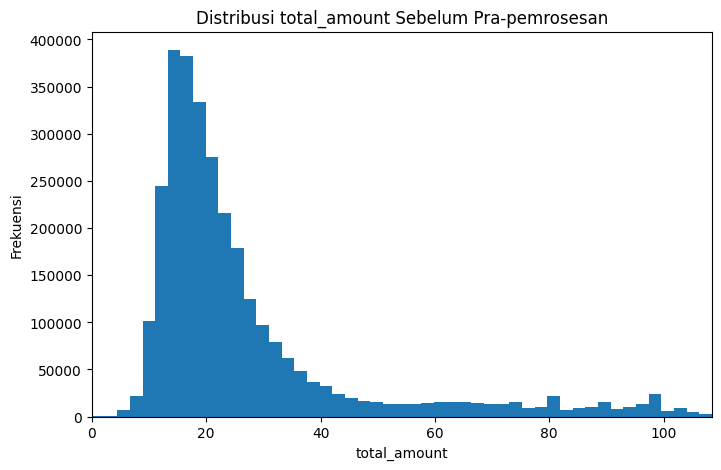

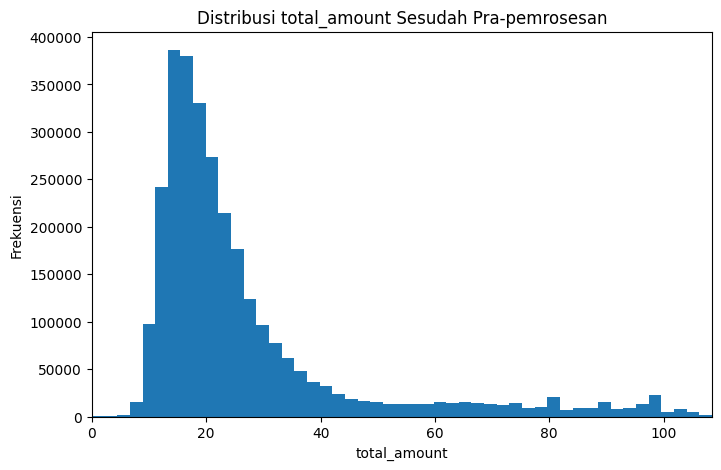

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Gunakan data sebelum dan sesudah pra-pemrosesan
sebelum = trip["total_amount"].dropna()
sesudah = bersih["total_amount"].dropna()

# Batas sumbu-x dibuat sama berdasarkan gabungan data
batas_x = np.quantile(
    pd.concat([sebelum, sesudah]),
    0.995
)

bins = np.linspace(0, batas_x, 50)

# Histogram sebelum pra-pemrosesan
plt.figure(figsize=(8, 5))
plt.hist(sebelum[sebelum <= batas_x], bins=bins)
plt.xlim(0, batas_x)
plt.xlabel("total_amount")
plt.ylabel("Frekuensi")
plt.title("Distribusi total_amount Sebelum Pra-pemrosesan")
plt.show()

# Histogram sesudah pra-pemrosesan
plt.figure(figsize=(8, 5))
plt.hist(sesudah[sesudah <= batas_x], bins=bins)
plt.xlim(0, batas_x)
plt.xlabel("total_amount")
plt.ylabel("Frekuensi")
plt.title("Distribusi total_amount Sesudah Pra-pemrosesan")
plt.show()

# P. Studi Kasus

## 1. Tabel Analitik Pricing

Tabel analitik dibuat dengan tingkat rincian satu baris untuk setiap `borough_naik` dan jam. `jam_mulai` diperoleh dengan membulatkan waktu pickup ke awal jam menggunakan `dt.floor("h")`.

Jumlah perjalanan dihitung dari jumlah baris, sedangkan tarif per mil dan kecepatan menggunakan **median** karena distribusi transaksi dapat memiliki nilai ekstrem. Suhu menggunakan nilai pertama pada jam tersebut dan `hujan` menggunakan nilai maksimum sehingga jam diberi tanda hujan jika terdapat kondisi hujan.

Kelompok dengan kurang dari 30 perjalanan dibuang karena jumlah observasinya terlalu kecil untuk digunakan sebagai pembanding.

In [31]:
# Membentuk tabel analitik per borough per jam
tabel_analitik = (
    bersih
    .assign(
        jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h")
    )
    .groupby(
        ["borough_naik", "jam_mulai"],
        observed=True
    )
    .agg(
        jumlah_perjalanan=("total_amount", "size"),
        rata_tarif_per_mil=("tarif_per_mil", "median"),
        rata_kecepatan=("kecepatan_mph", "median"),
        suhu_c=("suhu_c", "first"),
        hujan=("hujan", "max")
    )
    .reset_index()
)

# Hanya mempertahankan kelompok dengan minimal 30 perjalanan
tabel_analitik = tabel_analitik[
    tabel_analitik["jumlah_perjalanan"] >= 30
].copy()

print("Ukuran tabel analitik:", tabel_analitik.shape)
tabel_analitik.head()

Ukuran tabel analitik: (2094, 7)


,borough_naik,jam_mulai,jumlah_perjalanan,rata_tarif_per_mil,rata_kecepatan,suhu_c,hujan
626,Brooklyn,2023-01-01 00:00:00,86,6.9385,14.550,10.9,1
627,Brooklyn,2023-01-01 01:00:00,220,6.9820,13.715,10.6,1
628,Brooklyn,2023-01-01 02:00:00,256,6.6215,15.445,10.6,0
629,Brooklyn,2023-01-01 03:00:00,175,6.6160,16.390,10.5,0
630,Brooklyn,2023-01-01 04:00:00,74,6.9120,14.635,9.8,0


### Hasil

Tabel analitik menghasilkan **2.094 baris dan 7 kolom**. Setiap baris mewakili kombinasi `borough_naik` dan `jam_mulai` yang memiliki minimal 30 perjalanan.

Kolom yang dihasilkan mencakup jumlah perjalanan, median tarif per mil, median kecepatan, suhu, dan indikator hujan. Contoh pada data Brooklyn menunjukkan bahwa nilai tarif per mil dan kecepatan berbeda pada setiap jam, sedangkan `hujan` bernilai 1 atau 0 sesuai kondisi hujan pada jam tersebut.

## 2. Angka pembanding hujan vs tidak hujan

Untuk menguji dugaan pricing, nilai `rata_tarif_per_mil` dibandingkan antara jam hujan dan tidak hujan pada setiap borough.

Nilai yang dibandingkan adalah median dari tarif per mil per kelompok jam. Selisih dihitung sebagai tarif saat hujan dikurangi tarif saat tidak hujan. Hasil ini hanya menunjukkan hubungan pada data, bukan bukti bahwa hujan menyebabkan kenaikan tarif.

In [32]:
# Perbandingan tarif per mil saat hujan dan tidak hujan
perbandingan_pricing = (
    tabel_analitik
    .groupby(
        ["borough_naik", "hujan"],
        observed=True
    )["rata_tarif_per_mil"]
    .median()
    .unstack()
    .rename(columns={
        False: "tidak_hujan",
        True: "hujan"
    })
)

perbandingan_pricing["selisih"] = (
    perbandingan_pricing["hujan"]
    - perbandingan_pricing["tidak_hujan"]
)

perbandingan_pricing["persen_perubahan"] = (
    perbandingan_pricing["selisih"]
    / perbandingan_pricing["tidak_hujan"]
    * 100
)

print(perbandingan_pricing.round(3))

hujan         tidak_hujan   hujan  selisih  persen_perubahan
borough_naik                                                
Brooklyn            6.943   7.655    0.712            10.255
Manhattan          10.527  11.400    0.873             8.293
Queens              5.453   5.636    0.183             3.365
Unknown             8.726   9.886    1.160            13.300


### Hasil Perbandingan Tarif Saat Hujan dan Tidak Hujan

Hasil perbandingan menunjukkan bahwa median tarif per mil lebih tinggi pada kondisi hujan di seluruh borough yang memiliki data pembanding. Brooklyn mengalami kenaikan dari 6.943 menjadi 7.655 atau sebesar 10.255%. Manhattan meningkat dari 10.527 menjadi 11.400 atau 8.293%. Queens meningkat dari 5.453 menjadi 5.636 atau 3.365%, sedangkan kelompok Unknown meningkat dari 8.726 menjadi 9.886 atau 13.300%.

Secara deskriptif, hasil ini menunjukkan adanya hubungan antara kondisi hujan dan tarif per mil yang lebih tinggi. Namun, hasil ini belum membuktikan bahwa hujan secara langsung menyebabkan kenaikan tarif karena faktor lain, seperti jam sibuk, dapat terjadi bersamaan dengan hujan.

Hipotesis: “Tarif per mile rises during rainy hours in certain boroughs.”

Hasil data mendukung hipotesis secara deskriptif. Pada Brooklyn, Manhattan, Queens, dan kelompok Unknown, median tarif per mil saat hujan lebih tinggi dibandingkan saat tidak hujan. Kenaikannya masing-masing sebesar 10.255%, 8.293%, 3.365%, dan 13.300%.

## 3. Menyimpan tabel sebagai Parquet

Tabel analitik berhasil disimpan dalam format Parquet dengan ukuran **2.094 baris dan 7 kolom**. File disimpan di folder praktikum dan dapat digunakan kembali untuk analisis pricing tanpa perlu menjalankan ulang seluruh proses pengolahan data.

Kolom yang tersimpan adalah `borough_naik`, `jam_mulai`, `jumlah_perjalanan`, `rata_tarif_per_mil`, `rata_kecepatan`, `suhu_c`, dan `hujan`.

In [33]:
PATH_ANALITIK = os.path.join(
    DIR_SIMPAN,
    "tabel_analitik_pricing.parquet"
)

tabel_analitik.to_parquet(
    PATH_ANALITIK,
    index=False
)

print("Tabel analitik disimpan di:")
print(PATH_ANALITIK)

print("\nUkuran tabel:", tabel_analitik.shape)
print("\nKolom:")
print(tabel_analitik.columns.tolist())

Tabel analitik disimpan di:
/content/drive/MyDrive/BigData/Praktikum3/tabel_analitik_pricing.parquet

Ukuran tabel: (2094, 7)

Kolom:
['borough_naik', 'jam_mulai', 'jumlah_perjalanan', 'rata_tarif_per_mil', 'rata_kecepatan', 'suhu_c', 'hujan']


## 4. Membuat kamus_data.md
### Kamus Data — Tabel Analitik Pricing

| Kolom | Definisi | Satuan | Cara Penghitungan | Sumber |
|---|---|---|---|---|
| borough_naik | Borough berdasarkan lokasi pickup | kategori | Hasil join `PULocationID` dengan Taxi Zone Lookup | NYC TLC + Taxi Zone Lookup |
| jam_mulai | Awal jam perjalanan | datetime | `tpep_pickup_datetime.dt.floor("h")` | NYC TLC |
| jumlah_perjalanan | Jumlah perjalanan dalam satu borough dan jam | perjalanan | Jumlah baris (`size`) | NYC TLC |
| rata_tarif_per_mil | Median tarif per mil dalam satu borough dan jam | USD/mil | Median `tarif_per_mil` | NYC TLC |
| rata_kecepatan | Median kecepatan perjalanan dalam satu borough dan jam | mil/jam | Median `kecepatan_mph` | NYC TLC |
| suhu_c | Suhu pada jam tersebut | °C | Nilai pertama `suhu_c` pada kelompok jam | Open-Meteo |
| hujan | Penanda kondisi hujan | boolean | Nilai maksimum `hujan` pada kelompok jam; `True` jika terdapat hujan | Open-Meteo |

### Aturan Pembentukan

- Data berasal dari data perjalanan Yellow Taxi Januari 2023.
- Data zona berasal dari Taxi Zone Lookup.
- Data cuaca berasal dari Open-Meteo hourly archive.
- Hanya kelompok borough-jam dengan minimal 30 perjalanan yang dipertahankan.
- Tarif per mil dan kecepatan menggunakan median untuk mengurangi pengaruh nilai ekstrem.
- `hujan` mengikuti penanda hujan yang telah dibuat pada tahap feature engineering, yaitu kondisi curah hujan > 0,1 mm.

### Penelusuran Sumber

Setiap angka dalam tabel berasal dari agregasi data perjalanan yang telah melalui tahap preprocessing dan penggabungan dengan data zona serta cuaca.

Sumber utama:
1. NYC TLC Yellow Taxi Trip Data Januari 2023
2. NYC TLC Taxi Zone Lookup
3. Open-Meteo Hourly Archive

Periode analisis: Januari 2023.

In [37]:
kamus_data = """
# Kamus Data — Tabel Analitik Pricing

| Kolom | Definisi | Satuan | Cara Penghitungan | Sumber |
|---|---|---|---|---|
| borough_naik | Borough berdasarkan lokasi pickup | kategori | Hasil join `PULocationID` dengan Taxi Zone Lookup | NYC TLC + Taxi Zone Lookup |
| jam_mulai | Awal jam perjalanan | datetime | `tpep_pickup_datetime.dt.floor("h")` | NYC TLC |
| jumlah_perjalanan | Jumlah perjalanan dalam satu borough dan jam | perjalanan | Jumlah baris (`size`) | NYC TLC |
| rata_tarif_per_mil | Median tarif per mil dalam satu borough dan jam | USD/mil | Median `tarif_per_mil` | NYC TLC |
| rata_kecepatan | Median kecepatan perjalanan dalam satu borough dan jam | mil/jam | Median `kecepatan_mph` | NYC TLC |
| suhu_c | Suhu pada jam tersebut | °C | Nilai pertama `suhu_c` pada kelompok jam | Open-Meteo |
| hujan | Penanda kondisi hujan | boolean | Nilai maksimum `hujan` pada kelompok jam; `True` jika terdapat hujan | Open-Meteo |

## Aturan Pembentukan

- Data berasal dari data perjalanan Yellow Taxi Januari 2023.
- Data zona berasal dari Taxi Zone Lookup.
- Data cuaca berasal dari Open-Meteo hourly archive.
- Hanya kelompok borough-jam dengan minimal 30 perjalanan yang dipertahankan.
- Tarif per mil dan kecepatan menggunakan median untuk mengurangi pengaruh nilai ekstrem.
- `hujan` mengikuti penanda hujan yang telah dibuat pada tahap feature engineering, yaitu kondisi curah hujan > 0,1 mm.

## Penelusuran Sumber

Setiap angka dalam tabel berasal dari agregasi data perjalanan yang telah melalui tahap preprocessing dan penggabungan dengan data zona serta cuaca.

Sumber utama:
1. NYC TLC Yellow Taxi Trip Data Januari 2023
2. NYC TLC Taxi Zone Lookup
3. Open-Meteo Hourly Archive

Periode analisis: Januari 2023.
"""

PATH_KAMUS = os.path.join(
    DIR_SIMPAN,
    "kamus_data.md"
)

with open(PATH_KAMUS, "w", encoding="utf-8") as f:
    f.write(kamus_data)

print("Kamus data disimpan di:")
print(PATH_KAMUS)

Kamus data disimpan di:
/content/drive/MyDrive/BigData/Praktikum3/kamus_data.md


## 5. Keterbatasan dan Update Bulanan

### Keterbatasan

1. **Median digunakan sebagai representasi tarif dan kecepatan** karena data perjalanan dapat memiliki distribusi yang miring dan nilai ekstrem. Oleh karena itu, hasil tidak menggambarkan nilai rata-rata aritmetika.

2. **Data cuaca berasal dari satu titik pengamatan untuk seluruh kota**, sehingga kondisi hujan yang digunakan belum tentu mewakili kondisi cuaca pada setiap borough secara lokal.

3. **Korelasi tidak sama dengan kausalitas.** Kenaikan tarif per mil saat hujan belum dapat dianggap disebabkan oleh hujan karena hujan dapat terjadi bersamaan dengan jam sibuk atau faktor lain yang memengaruhi tarif.

4. **Kelompok dengan kurang dari 30 perjalanan dihapus**, sehingga beberapa kombinasi borough dan jam tidak masuk ke tabel analitik.

5. **Analisis hanya menggunakan Januari 2023**, sehingga hasil belum dapat langsung digeneralisasi ke bulan atau periode lainnya.

### Update Bulanan

Untuk pembaruan setiap bulan, periode data dapat dijadikan parameter pada pipeline. Proses dimulai dengan mengambil data perjalanan dan cuaca untuk bulan baru, melakukan validasi dan preprocessing, menggabungkan data zona serta cuaca, kemudian membentuk tabel analitik dengan aturan agregasi yang sama. Hasil disimpan sebagai file Parquet dengan periode yang sesuai dan `kamus_data.md` tetap digunakan sebagai dokumentasi struktur data. Sebelum tabel diperbarui, jumlah baris, duplikasi, missing value, dan keberhasilan join perlu divalidasi agar perubahan data dapat ditelusuri. Penjadwalan otomatis dapat dilakukan menggunakan scheduler seperti cron atau workflow terjadwal setelah pipeline dibuat dalam bentuk script.

# Q.2 Latihan

## Q.1 Latihan 1 — Kecepatan Unduh dan Cache

Fungsi `unduh_aman()` dimodifikasi agar mencatat waktu unduhan dan menghitung kecepatan dalam MB/detik. Jika file sudah tersedia, fungsi tidak melakukan unduhan ulang dan menggunakan cache.

Fungsi dijalankan dua kali pada file yang sama. Panggilan pertama melakukan unduhan, sedangkan panggilan kedua seharusnya menampilkan pesan bahwa cache ditemukan.

In [38]:
import time

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry, penulisan atomik, dan informasi kecepatan."""

    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        print("tidak ada unduhan ulang")
        return tujuan

    sementara = tujuan + ".part"

    for i in range(percobaan):
        try:
            t0 = time.perf_counter()

            with requests.get(
                url,
                stream=True,
                timeout=60
            ) as r:
                r.raise_for_status()

                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)

            ukuran_mb = os.path.getsize(sementara) / 1024**2

            if ukuran_mb == 0:
                raise IOError("berkas kosong")

            os.replace(sementara, tujuan)

            detik = time.perf_counter() - t0
            kecepatan = ukuran_mb / detik

            print(
                f"unduh selesai: {ukuran_mb:.2f} MB "
                f"dalam {detik:.2f} detik"
            )
            print(
                f"kecepatan unduh: {kecepatan:.2f} MB/detik"
            )

            return tujuan

        except Exception as e:
            jeda = jeda_awal * (2 ** i)
            print(
                f"percobaan {i+1} gagal ({e}); "
                f"menunggu {jeda}s"
            )
            time.sleep(jeda)

    raise RuntimeError(
        f"gagal mengunduh setelah {percobaan} percobaan: {url}"
    )


# Gunakan file khusus untuk membuktikan dua kondisi
PATH_LATIHAN1 = os.path.join(
    DIR_MENTAH,
    "latihan1_yellow_tripdata.parquet"
)

# Hapus file uji jika sebelumnya sudah ada
if os.path.exists(PATH_LATIHAN1):
    os.remove(PATH_LATIHAN1)

print("=== Panggilan pertama ===")
unduh_aman(
    URL_TRIP,
    PATH_LATIHAN1
)

print("\n=== Panggilan kedua ===")
unduh_aman(
    URL_TRIP,
    PATH_LATIHAN1
)

=== Panggilan pertama ===
unduh selesai: 45.46 MB dalam 0.77 detik
kecepatan unduh: 58.70 MB/detik

=== Panggilan kedua ===
cache ditemukan: latihan1_yellow_tripdata.parquet
tidak ada unduhan ulang


'/content/lapisan_mentah/latihan1_yellow_tripdata.parquet'

### Hasil Latihan 1

Pada panggilan pertama, file berukuran **45.46 MB** berhasil diunduh dalam **0.77 detik** dengan kecepatan **58.70 MB/detik**.

Pada panggilan kedua, fungsi mendeteksi bahwa file sudah tersedia sehingga menggunakan **cache** dan tidak melakukan unduhan ulang. Hal ini ditunjukkan oleh pesan `cache ditemukan` dan `tidak ada unduhan ulang`.

Hasil ini membuktikan bahwa `unduh_aman()` dapat menggunakan cache pada pemanggilan berikutnya.

## Q.2 Latihan 2 — Aturan Kualitas Tambahan

Dua aturan baru ditambahkan ke pemeriksaan K-6. `tip_amount` harus bernilai minimal 0 sebagai aturan validitas. Selain itu, `total_amount` harus lebih besar atau sama dengan jumlah `fare_amount` dan `tip_amount` sebagai aturan konsistensi antar kolom.

Persentase kegagalan dihitung dengan cara yang sama seperti pada K-6.

In [39]:
aturan_q2 = aturan.copy()

# Aturan baru 1: validitas tip_amount
aturan_q2["validitas: tip_amount >= 0"] = (
    trip["tip_amount"] >= 0
)

# Aturan baru 2: konsistensi total dengan fare + tip
aturan_q2["konsistensi: total >= fare + tip"] = (
    trip["total_amount"]
    >= trip["fare_amount"] + trip["tip_amount"]
)

laporan_q2 = pd.DataFrame([
    {
        "aturan": nama,
        "lulus": int(mask.sum()),
        "gagal": int((~mask).sum()),
        "persen_gagal": round(
            100 * (~mask).mean(),
            3
        )
    }
    for nama, mask in aturan_q2.items()
]).sort_values(
    "persen_gagal",
    ascending=False
)

laporan_q2

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
9,konsistensi: total >= fare + tip,3041605,25160,0.820
6,konsistensi: total >= fare,3041743,25023,0.816
8,validitas: tip_amount >= 0,3066540,225,0.007
7,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


### Hasil Latihan 2

Dua aturan kualitas tambahan berhasil diterapkan. Aturan validitas `tip_amount >= 0` memiliki **225 baris gagal atau 0,007%**, sedangkan aturan konsistensi `total_amount >= fare_amount + tip_amount` memiliki **25.160 baris gagal atau 0,820%**.

Aturan konsistensi memiliki persentase kegagalan yang lebih tinggi dibandingkan aturan validitas `tip_amount`, sehingga terdapat lebih banyak data yang tidak memenuhi hubungan antara total pembayaran, tarif, dan tip.

| Aturan baru                                |  Gagal | Persentase |
| ------------------------------------------ | -----: | ---------: |
| `tip_amount >= 0`                          |    225 | **0,007%** |
| `total_amount >= fare_amount + tip_amount` | 25.160 | **0,820%** |


## Q.3 Latihan 3 — Borough Asal dan Tujuan

Join lokasi tujuan dilakukan menggunakan `DOLocationID` terhadap `LocationID` pada tabel zona. Setelah itu, jumlah perjalanan dihitung berdasarkan pasangan borough asal dan tujuan.

Hasil diurutkan dari jumlah perjalanan terbanyak untuk mendapatkan sepuluh pasangan borough yang paling sibuk.

In [40]:
# Tabel zona tujuan
zona_tujuan = (
    zona[["LocationID", "Borough"]]
    .rename(columns={
        "LocationID": "DOLocationID",
        "Borough": "borough_tujuan"
    })
)

# Join lokasi tujuan
bersih_tujuan = bersih.merge(
    zona_tujuan,
    on="DOLocationID",
    how="left",
    validate="many_to_one"
)

# Hitung pasangan borough asal-tujuan
top10_pasangan = (
    bersih_tujuan
    .groupby(
        ["borough_naik", "borough_tujuan"],
        dropna=False
    )
    .size()
    .reset_index(name="jumlah_perjalanan")
    .sort_values(
        "jumlah_perjalanan",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

top10_pasangan

,borough_naik,borough_tujuan,jumlah_perjalanan
0,Manhattan,Manhattan,2491566
1,Queens,Manhattan,155261
2,Manhattan,Queens,82354
3,Manhattan,Brooklyn,62986
4,Queens,Queens,59146
5,Queens,Brooklyn,42187
6,Unknown,Manhattan,18432
7,Unknown,Unknown,13562
8,Manhattan,Bronx,8865
9,Brooklyn,Brooklyn,7910


### Hasil Latihan 3

Hasil join `DOLocationID` menghasilkan sepuluh pasangan borough asal–tujuan dengan jumlah perjalanan terbanyak. Pasangan dengan perjalanan terbanyak adalah **Manhattan–Manhattan** sebanyak **2.491.566 perjalanan**, diikuti **Queens–Manhattan** sebanyak **155.261 perjalanan**.

Hasil ini menunjukkan bahwa perjalanan dengan asal dan tujuan di dalam borough yang sama juga mendominasi beberapa pasangan dengan frekuensi tinggi.

## Q.4 Latihan 4 — StandardScaler dan MinMaxScaler

`StandardScaler` mengubah fitur berdasarkan mean dan simpangan baku, sedangkan `MinMaxScaler` mengubah nilai ke rentang tertentu, yaitu 0 sampai 1 secara default.

Kedua scaler di-fit hanya menggunakan data latih agar tidak terjadi data leakage. Rentang hasil kemudian dibandingkan pada data latih.

In [41]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# StandardScaler
scaler_standard = StandardScaler().fit(
    latih[FITUR_NUM]
)

standard_num = scaler_standard.transform(
    latih[FITUR_NUM]
)

# MinMaxScaler
scaler_minmax = MinMaxScaler().fit(
    latih[FITUR_NUM]
)

minmax_num = scaler_minmax.transform(
    latih[FITUR_NUM]
)

# Ringkasan rentang hasil
perbandingan_scaling = pd.DataFrame({
    "fitur": FITUR_NUM,

    "standard_min": standard_num.min(axis=0),
    "standard_max": standard_num.max(axis=0),

    "minmax_min": minmax_num.min(axis=0),
    "minmax_max": minmax_num.max(axis=0)
})

perbandingan_scaling.round(3)

,fitur,standard_min,standard_max,minmax_min,minmax_max
0,trip_distance_capped,-0.794,4.247,0.0,1.0
1,durasi_menit,-1.226,13.925,0.0,1.0
2,suhu_c,-2.288,3.347,0.0,1.0


### Hasil Latihan 4

Hasil perbandingan menunjukkan bahwa `StandardScaler` menghasilkan rentang yang berbeda untuk setiap fitur karena data distandarkan berdasarkan mean dan simpangan baku. Rentang hasilnya adalah -0,794 sampai 4,247 untuk `trip_distance_capped`, -1,226 sampai 13,925 untuk `durasi_menit`, dan -2,288 sampai 3,347 untuk `suhu_c`.

Sementara itu, `MinMaxScaler` mengubah seluruh fitur ke rentang **0 sampai 1**.

Perbedaan scaling penting untuk algoritma yang sensitif terhadap skala dan jarak, seperti KNN, K-Means, dan beberapa algoritma SVM. Untuk algoritma berbasis pohon seperti Decision Tree dan Random Forest, perbedaan skala umumnya tidak terlalu berpengaruh.


## Q.5 Latihan 5 — Validasi `many_to_one`

Parameter `validate="many_to_one"` digunakan untuk memastikan bahwa setiap kunci pada tabel kanan hanya memiliki satu pasangan. Untuk membuktikannya, satu baris pada tabel zona digandakan sehingga `LocationID` menjadi tidak unik.

Join kemudian dijalankan kembali. Karena tabel kanan memiliki kunci yang duplikat, pandas seharusnya menghasilkan `MergeError`. Setelah pengujian selesai, tabel zona dikembalikan ke salinan aslinya.

In [44]:
from pandas.errors import MergeError

# Simpan kondisi asli
zona_asli = zona.copy(deep=True)

# Buat tabel uji dengan satu LocationID duplikat
zona_uji = pd.concat(
    [
        zona.copy(),
        zona.iloc[[0]].copy()
    ],
    ignore_index=True
)

print(
    "LocationID unik sebelum:",
    zona["LocationID"].is_unique
)

print(
    "LocationID unik setelah digandakan:",
    zona_uji["LocationID"].is_unique
)

try:
    uji_many_to_one = bersih.merge(
        zona_uji[
            ["LocationID", "Borough"]
        ].rename(
            columns={
                "Borough": "borough_uji"
            }
        ),
        left_on="PULocationID",
        right_on="LocationID",
        how="left",
        validate="many_to_one"
    )

except MergeError as e:
    print("ERROR BERHASIL DITANGKAP:")
    print(type(e).__name__)
    print(e)

# Kembalikan tabel zona ke kondisi semula
zona = zona_asli.copy(deep=True)

print(
    "\nLocationID unik setelah dipulihkan:",
    zona["LocationID"].is_unique
)

LocationID unik sebelum: True
LocationID unik setelah digandakan: False
ERROR BERHASIL DITANGKAP:
MergeError
Merge keys are not unique in right dataset; not a many-to-one merge

LocationID unik setelah dipulihkan: True


### Hasil Latihan 5

Sebelum pengujian, `LocationID` pada tabel zona bersifat unik. Setelah satu baris digandakan, keunikan `LocationID` menjadi `False`.

Saat join dijalankan dengan `validate="many_to_one"`, pandas menghasilkan `MergeError` dengan pesan `Merge keys are not unique in right dataset; not a many-to-one merge`. Hal ini membuktikan bahwa parameter tersebut berhasil mendeteksi adanya kunci duplikat pada tabel kanan.

Setelah pengujian selesai, tabel zona dikembalikan ke kondisi semula dan `LocationID` kembali unik.

## Q.6 Latihan 6 — Pipeline Inkremental

Fungsi `pipeline_inkremental(bulan)` digunakan untuk memproses hanya bulan yang belum tersedia pada direktori keluaran. Nama bulan digunakan sebagai identitas output sehingga setiap bulan memiliki lokasi penyimpanan sendiri.

Jika output bulan tersebut sudah ada, pipeline dilewati. Dengan demikian, pemanggilan kedua pada bulan yang sama tidak membuat berkas baru dan menunjukkan sifat idempoten.

In [42]:
import calendar

DIR_INCREMENTAL = os.path.join(
    DIR_KURASI,
    "trips_bersih_incremental"
)

os.makedirs(
    DIR_INCREMENTAL,
    exist_ok=True
)


def pipeline_inkremental(bulan):
    """
    Memproses satu bulan hanya jika output bulan tersebut
    belum tersedia.

    Format bulan: YYYY-MM
    """

    periode = pd.Period(
        bulan,
        freq="M"
    )

    bulan_str = str(periode)

    # Direktori output khusus bulan
    out_bulan = os.path.join(
        DIR_INCREMENTAL,
        bulan_str
    )

    # Cek apakah bulan sudah pernah diproses
    if os.path.exists(out_bulan) and os.listdir(out_bulan):
        print(
            f"[SKIP] {bulan_str} sudah ada di output."
        )
        print(
            "Tidak ada berkas baru yang dibuat."
        )
        return False

    os.makedirs(
        out_bulan,
        exist_ok=True
    )

    # Path data trip bulan tersebut
    nama_file = (
        f"yellow_tripdata_{bulan_str}.parquet"
    )

    path_trip_bulan = os.path.join(
        DIR_MENTAH,
        nama_file
    )

    url_trip_bulan = (
        "https://d37ci6vzurychx.cloudfront.net/"
        "trip-data/"
        f"{nama_file}"
    )

    # Unduh data trip
    unduh_aman(
        url_trip_bulan,
        path_trip_bulan
    )

    # Tentukan tanggal awal dan akhir bulan
    tanggal_awal = periode.start_time.strftime(
        "%Y-%m-%d"
    )
    tanggal_akhir = periode.end_time.strftime(
        "%Y-%m-%d"
    )

    # Ambil data cuaca untuk bulan tersebut
    cuaca_bulan = ambil_cuaca(
        tanggal_awal,
        tanggal_akhir
    )

    cuaca_bulan["time"] = pd.to_datetime(
        cuaca_bulan["time"]
    )

    cuaca_bulan = cuaca_bulan.rename(
        columns={
            "time": "jam_mulai",
            "temperature_2m": "suhu_c",
            "precipitation": "hujan_mm"
        }
    )

    # Jalankan pipeline K-10
    hasil_bulan = pipeline(
        path_trip_bulan,
        PATH_ZONA,
        cuaca_bulan,
        tarif_referensi
    )

    # Simpan output bulan
    hasil_bulan["tanggal"] = (
        hasil_bulan[
            "tpep_pickup_datetime"
        ]
        .dt.date
        .astype(str)
    )

    hasil_bulan.to_parquet(
        out_bulan,
        partition_cols=["borough_naik"],
        index=False
    )

    print(
        f"[SELESAI] {bulan_str}: "
        f"{len(hasil_bulan):,} baris"
    )

    print(
        "Output:",
        out_bulan
    )

    return True

**Bukti idempotensi**

In [43]:
# Pastikan bulan uji belum ada
OUT_UJI = os.path.join(
    DIR_INCREMENTAL,
    "2023-01"
)

if os.path.exists(OUT_UJI):
    shutil.rmtree(OUT_UJI)

print("=== Panggilan pertama ===")

hasil_pertama = pipeline_inkremental(
    "2023-01"
)

jumlah_file_pertama = sum(
    len(files)
    for _, _, files in os.walk(OUT_UJI)
)

print(
    "Jumlah file setelah panggilan pertama:",
    jumlah_file_pertama
)

print("\n=== Panggilan kedua ===")

hasil_kedua = pipeline_inkremental(
    "2023-01"
)

jumlah_file_kedua = sum(
    len(files)
    for _, _, files in os.walk(OUT_UJI)
)

print(
    "Jumlah file setelah panggilan kedua:",
    jumlah_file_kedua
)

print(
    "\nIdempoten?",
    hasil_kedua is False
    and jumlah_file_kedua == jumlah_file_pertama
)

=== Panggilan pertama ===
cache ditemukan: yellow_tripdata_2023-01.parquet
tidak ada unduhan ulang
Validasi lulus: 2,986,910 baris x 17 kolom
[SELESAI] 2023-01: 2,986,910 baris
Output: /content/lapisan_terkurasi/trips_bersih_incremental/2023-01
Jumlah file setelah panggilan pertama: 8

=== Panggilan kedua ===
[SKIP] 2023-01 sudah ada di output.
Tidak ada berkas baru yang dibuat.
Jumlah file setelah panggilan kedua: 8

Idempoten? True


### Hasil Latihan 6

Pada panggilan pertama, pipeline memproses bulan `2023-01` dan menghasilkan **2.986.910 baris** yang disimpan pada direktori `/content/lapisan_terkurasi/trips_bersih_incremental/2023-01`. Terdapat **8 berkas** setelah proses pertama.

Pada panggilan kedua, pipeline mendeteksi bahwa output `2023-01` sudah tersedia sehingga proses dilewati. Jumlah berkas tetap **8 berkas** dan tidak ada berkas baru yang dibuat.

Hasil `Idempoten? True` membuktikan bahwa `pipeline_inkremental(bulan)` bersifat idempoten untuk bulan yang sama.